# MatrixDesing

В этом ноутбуке я построю матрицу взаимодействия и протестирую AILS модель.

## Импорт библиоткек

In [27]:
import pandas as pd
import numpy as np
import implicit
import os
from scipy import sparse
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder  
import matplotlib.pyplot as plt
from pathlib import Path

## Загрузка данных

In [32]:
BASE_PATH = os.path.abspath("../../../Tables/CleanTable")

In [37]:
users_clean = pd.read_csv(os.path.join(BASE_PATH, 'users_clean.csv'), encoding='utf-8')
items_dim = pd.read_csv(os.path.join(BASE_PATH, 'items_dim.csv'), encoding='utf-8')
user_items = pd.read_csv(os.path.join(BASE_PATH, 'user_item_clean.csv'), encoding='utf-8')

## Разбиение df на train/val/test (Time-based split)

Для актуальности данных буду использовать Time-based split в таком формате:
- 75 дней (с 5 декабря по 18 февраля) на train
- 7 дней (с 19 февраля по 25 февраля) на val 
- 7 дней (с 26 февраля по 4 марта) на test


Приведем столбец "Время визита" к datetime64

In [38]:
user_items.dtypes

Имя мастера                  str
Специализация мастера        str
Имя клиента                  str
Время визита                 str
Категория услуги             str
Название услуги              str
Стоимость, руб           float64
Категория                    str
id_user                    int64
id_item                    int64
dtype: object

In [39]:
user_items['Время визита'] = pd.to_datetime(user_items['Время визита'], errors='coerce')
user_items.dtypes

Имя мастера                         str
Специализация мастера               str
Имя клиента                         str
Время визита             datetime64[us]
Категория услуги                    str
Название услуги                     str
Стоимость, руб                  float64
Категория                           str
id_user                           int64
id_item                           int64
dtype: object

Сортируем по дате

In [40]:
user_items = user_items.sort_values(by='Время визита', ascending=False)

In [44]:
f"Количество уникальных дат визитов: {user_items['Время визита'].dt.date.nunique()}"

'Количество уникальных дат визитов: 89'

### Разбиваем user_items на 3 DataFrame по времени визита

In [45]:
val_start = pd.Timestamp('2026-02-19')
test_start = pd.Timestamp('2026-02-26')

In [46]:
train_df = user_items[user_items['Время визита'] < val_start].copy()
val_df = user_items[(user_items['Время визита'] >= val_start) & (user_items['Время визита'] < test_start)].copy()
test_df = user_items[user_items['Время визита'] >= test_start].copy()

In [47]:
train_df.shape, val_df.shape, test_df.shape

((6211, 10), (273, 10), (223, 10))

Теперь важно оставить в val и test только тех, кто был в train, чтобы IALS не выдал ошибку 

In [48]:
known_users = set(train_df['id_user'].unique())
known_items = set(train_df['id_item'].unique())

In [49]:
val_df = val_df[val_df['id_user'].isin(known_users) & val_df['id_item'].isin(known_items)]
test_df = test_df[test_df['id_user'].isin(known_users) & test_df['id_item'].isin(known_items)]

In [50]:
train_df.shape, val_df.shape, test_df.shape

((6211, 10), (221, 10), (167, 10))

## Построение матрицы __User-Item__

Формула для Confidence (weight)

__Weight = 1 + log(N)__, где N - количество посещений

Такая формула была выбрана, потому что она:
1)  Учитывает размерность самых частых услуг (log сгладит услуги с крупными посещениями).
2) Учитывает частоту посещений и поощеряет услугу, если клиент часто на неё ходит.

Тогда матрица будет в формате:

`id_user` | `id_item` | `Weight`

#### Считаем Weight

In [51]:
train_matrix = train_df.groupby(['id_user', 'id_item']).size().reset_index(name='N_visits')
test_matrix = test_df.groupby(['id_user', 'id_item']).size().reset_index(name='N_visits')
val_matrix = val_df.groupby(['id_user', 'id_item']).size().reset_index(name='N_visits')

In [58]:
print('train_matrix:', train_matrix.head(3), '\n',
       'test_matrix:', test_matrix.head(3), '\n',
         'val_matrix:', val_matrix.head(3), sep='\n')

train_matrix:
   id_user  id_item  N_visits
0        7      104         2
1        7      130         1
2        9      130         1


test_matrix:
   id_user  id_item  N_visits
0       77      104         1
1       79        8         1
2       83       13         1


val_matrix:
   id_user  id_item  N_visits
0        9      130         1
1       12      104         1
2       58       40         1


In [59]:
train_matrix['confidence'] = 1 + np.log(train_matrix['N_visits'])
test_matrix['confidence'] = 1 + np.log(test_matrix['N_visits'])
val_matrix['confidence'] = 1 + np.log(val_matrix['N_visits'])

In [60]:
print('train_matrix:', train_matrix.head(3), '\n',
       'test_matrix:', test_matrix.head(3), '\n',
         'val_matrix:', val_matrix.head(3), sep='\n')

train_matrix:
   id_user  id_item  N_visits  confidence
0        7      104         2    1.693147
1        7      130         1    1.000000
2        9      130         1    1.000000


test_matrix:
   id_user  id_item  N_visits  confidence
0       77      104         1         1.0
1       79        8         1         1.0
2       83       13         1         1.0


val_matrix:
   id_user  id_item  N_visits  confidence
0        9      130         1         1.0
1       12      104         1         1.0
2       58       40         1         1.0


In [61]:
''' 
# 1. Считаем посещения с весами
user_item_matrix = user_items.groupby(['id_user', 'id_item']).size().reset_index(name='N_visits')
print(user_item_matrix, end='\n'*5)
# 2. Weight = 1 + log(N)
user_item_matrix['confidence'] = 1 + np.log(user_item_matrix['N_visits'])
print(user_item_matrix)'''

" \n# 1. Считаем посещения с весами\nuser_item_matrix = user_items.groupby(['id_user', 'id_item']).size().reset_index(name='N_visits')\nprint(user_item_matrix, end='\n'*5)\n# 2. Weight = 1 + log(N)\nuser_item_matrix['confidence'] = 1 + np.log(user_item_matrix['N_visits'])\nprint(user_item_matrix)"

#### CSR матрица

Требуедтся переопределить id, из-за того что в них есть пропуски и матрица из-за слишком разряженная

In [62]:
class IDMapper:
    def __init__(self, ids):
        self.unique_ids = sorted(set(ids))
        self.id_to_idx = {id_: i for i, id_ in enumerate(self.unique_ids)}
        self.idx_to_id = {i: id_ for i, id_ in enumerate(self.unique_ids)}

    def to_idx(self, ids):
        return ids.map(self.id_to_idx)

    @property
    def size(self):
        return len(self.unique_ids)

In [63]:
user_mapper = IDMapper(user_items['id_user'])
item_mapper = IDMapper(user_items['id_item'])

In [64]:
rows_train = user_mapper.to_idx(train_matrix['id_user'])
cols_train = item_mapper.to_idx(train_matrix['id_item'])
data_train = train_matrix['confidence']

rows_test = user_mapper.to_idx(test_matrix['id_user'])
cols_test = item_mapper.to_idx(test_matrix['id_item'])
data_test = test_matrix['confidence']

rows_val = user_mapper.to_idx(val_matrix['id_user'])
cols_val = item_mapper.to_idx(val_matrix['id_item'])
data_val = val_matrix['confidence']

In [69]:
train_sparse = sparse.csr_matrix((data_train, (rows_train, cols_train)),
                                  shape=(user_mapper.size, item_mapper.size))

In [70]:
test_sparse = sparse.csr_matrix((data_test, (rows_test, cols_test)),
                                  shape=(user_mapper.size, item_mapper.size))

In [71]:
val_sparse = sparse.csr_matrix((data_val, (rows_val, cols_val)),
                                  shape=(user_mapper.size, item_mapper.size))

In [68]:
train_sparse.shape, test_sparse.shape, val_sparse.shape

((1264, 161), (1264, 161), (1264, 161))

#### Оценка матрицы

In [72]:
import numpy as np
print("\n=== РАСПРЕДЕЛЕНИЕ ВЕСОВ 1+log(N) ===")
print('train_sparse:')
weights = train_sparse.data
for i in range(1, 11):
    count = np.sum(weights >= 1 + np.log(i))
    pct = count / len(weights) * 100
    print(f"N={i} → вес≥{1+np.log(i):.2f}: {count} ({pct:.1f}%)")



=== РАСПРЕДЕЛЕНИЕ ВЕСОВ 1+log(N) ===
train_sparse:
N=1 → вес≥1.00: 2003 (100.0%)
N=2 → вес≥1.69: 507 (25.3%)
N=3 → вес≥2.10: 180 (9.0%)
N=4 → вес≥2.39: 85 (4.2%)
N=5 → вес≥2.61: 52 (2.6%)
N=6 → вес≥2.79: 47 (2.3%)
N=7 → вес≥2.95: 41 (2.0%)
N=8 → вес≥3.08: 35 (1.7%)
N=9 → вес≥3.20: 33 (1.6%)
N=10 → вес≥3.30: 29 (1.4%)


In [73]:
import numpy as np
print("\n=== РАСПРЕДЕЛЕНИЕ ВЕСОВ 1+log(N) ===")
print('test_sparse:')
weights = test_sparse.data
for i in range(1, 11):
    count = np.sum(weights >= 1 + np.log(i))
    pct = count / len(weights) * 100
    print(f"N={i} → вес≥{1+np.log(i):.2f}: {count} ({pct:.1f}%)")



=== РАСПРЕДЕЛЕНИЕ ВЕСОВ 1+log(N) ===
test_sparse:
N=1 → вес≥1.00: 164 (100.0%)
N=2 → вес≥1.69: 3 (1.8%)
N=3 → вес≥2.10: 0 (0.0%)
N=4 → вес≥2.39: 0 (0.0%)
N=5 → вес≥2.61: 0 (0.0%)
N=6 → вес≥2.79: 0 (0.0%)
N=7 → вес≥2.95: 0 (0.0%)
N=8 → вес≥3.08: 0 (0.0%)
N=9 → вес≥3.20: 0 (0.0%)
N=10 → вес≥3.30: 0 (0.0%)


In [74]:
import numpy as np
print("\n=== РАСПРЕДЕЛЕНИЕ ВЕСОВ 1+log(N) ===")
print('val_sparse:')
weights = val_sparse.data
for i in range(1, 11):
    count = np.sum(weights >= 1 + np.log(i))
    pct = count / len(weights) * 100
    print(f"N={i} → вес≥{1+np.log(i):.2f}: {count} ({pct:.1f}%)")



=== РАСПРЕДЕЛЕНИЕ ВЕСОВ 1+log(N) ===
val_sparse:
N=1 → вес≥1.00: 218 (100.0%)
N=2 → вес≥1.69: 3 (1.4%)
N=3 → вес≥2.10: 0 (0.0%)
N=4 → вес≥2.39: 0 (0.0%)
N=5 → вес≥2.61: 0 (0.0%)
N=6 → вес≥2.79: 0 (0.0%)
N=7 → вес≥2.95: 0 (0.0%)
N=8 → вес≥3.08: 0 (0.0%)
N=9 → вес≥3.20: 0 (0.0%)
N=10 → вес≥3.30: 0 (0.0%)


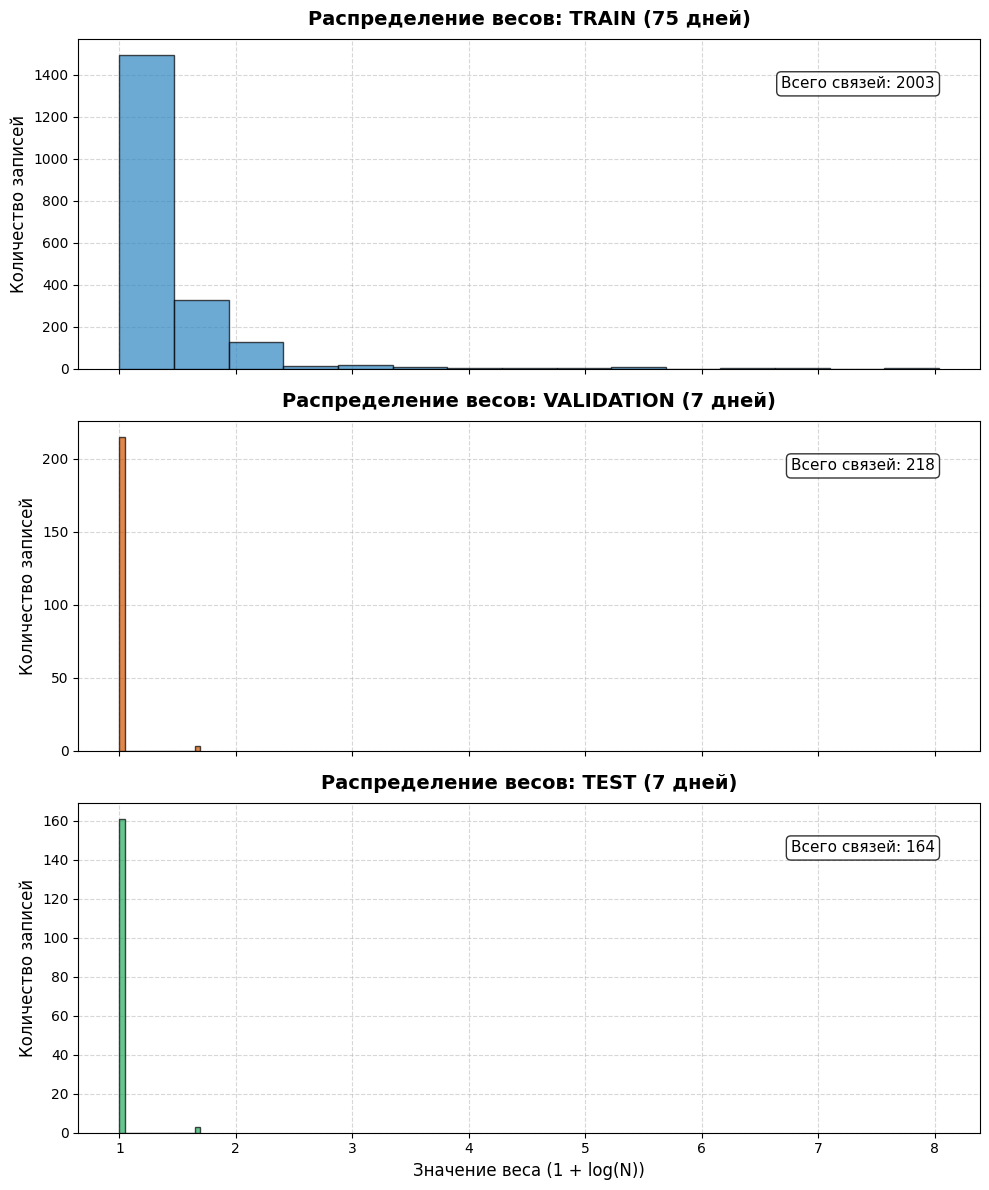

In [76]:
weights_list = [train_sparse.data, val_sparse.data, test_sparse.data]
titles = ['Распределение весов: TRAIN (75 дней)', 
          'Распределение весов: VALIDATION (7 дней)', 
          'Распределение весов: TEST (7 дней)']
colors = ['#2E86C1', '#D35400', '#27AE60']

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

for i, ax in enumerate(axes):
    # Рисуем гистограмму
    n, bins, patches = ax.hist(weights_list[i], bins=15, color=colors[i], 
                               alpha=0.7, edgecolor='black', zorder=3)
    
    # Настройка заголовков и осей
    ax.set_title(titles[i], fontsize=14, fontweight='bold', pad=10)
    ax.set_ylabel('Количество записей', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5, zorder=0)
    
    # Добавляем аннотацию с общим количеством связей
    ax.annotate(f'Всего связей: {len(weights_list[i])}', 
                xy=(0.95, 0.85), xycoords='axes fraction',
                fontsize=11, ha='right', bbox=dict(boxstyle="round", fc="white", alpha=0.8))

# Общая подпись для оси X
plt.xlabel('Значение веса (1 + log(N))', fontsize=12)

# Автоматическое выравнивание, чтобы заголовки не налезали на графики
plt.tight_layout()
plt.show()

In [78]:
print("=== БАЗОВАЯ ИНФОРМАЦИЯ ===")
print(f"Форма матрицы: {train_sparse.shape}")
print(f"NNZ (непустых): {train_sparse.nnz}")
print(f"Доля заполненности: {train_sparse.nnz / (train_sparse.shape[0] * train_sparse.shape[1]):.4f}")
print(f"Диапазон весов: {train_sparse.data.min():.2f} → {train_sparse.data.max():.2f}")
print(f"Средний вес: {train_sparse.data.mean():.2f}")

=== БАЗОВАЯ ИНФОРМАЦИЯ ===
Форма матрицы: (1264, 161)
NNZ (непустых): 2003
Доля заполненности: 0.0098
Диапазон весов: 1.00 → 8.04
Средний вес: 1.26


In [82]:
check = train_df[(train_df['id_user'] == 2445) & (train_df['id_item'] == 9)]
check.head()

,Имя мастера,Специализация мастера,Имя клиента,Время визита,Категория услуги,Название услуги,"Стоимость, руб",Категория,id_user,id_item
5320,Элгиза,Мастер маникюра,Галина,2025-12-05 11:30:00,Маникюр / Педикюр,покрытие,165.0,Сотрудник важен,2445,9
5317,Элгиза,Мастер маникюра,Галина,2025-12-05 11:30:00,Маникюр / Педикюр,покрытие,1450.0,Сотрудник важен,2445,9
5332,Элгиза,Мастер маникюра,Галина,2025-12-05 11:30:00,Маникюр / Педикюр,покрытие,1450.0,Сотрудник важен,2445,9
5314,Элгиза,Мастер маникюра,Галина,2025-12-05 11:30:00,Маникюр / Педикюр,покрытие,1450.0,Сотрудник важен,2445,9
5325,Элгиза,Мастер маникюра,Галина,2025-12-05 11:30:00,Маникюр / Педикюр,покрытие,1650.0,Сотрудник важен,2445,9


In [79]:
print(train_matrix.nlargest(5, 'confidence'))

      id_user  id_item  N_visits  confidence
1616     2445        9      1140    8.038784
1617     2445       10       809    7.695799
1631     2445       40       365    6.899897
1664     2445      104       228    6.429346
1704     2445      192        98    5.584967


In [86]:
user_items[user_items['id_user'] != 2445].shape

(2963, 10)

In [90]:
user_items.shape[0]

6707

In [ ]:
user_items.shape[0] - user_items[user_items['id_user'] == 2445].shape[0]

2963

In [80]:
users_clean[users_clean['id_user'] == 2445]

,id_user,Имя,Телефон,Категории,Оплачено в руб,Последний визит
2306,2445,Галина,79776467858,обычный,348116.0,2026-02-26 10:00:00


#### Сохранение матрицы

In [106]:
result_path = Path('../../../results/matrices')


In [107]:
sparse.save_npz(result_path / 'artnail_user_item_sparse_update.npz', user_item_sparse)
print(f"  Путь: {result_path / 'artnail_user_item_sparse.npz'}")
print(f"  Размер: {os.path.getsize(result_path / 'artnail_user_item_sparse.npz') / 1024:.1f} КБ")

  Путь: ..\..\..\results\matrices\artnail_user_item_sparse.npz
  Размер: 4.0 КБ
